# UAS Bengkel Koding - Customer Churn Prediction

Dataset: Sales and Marketing Customer (15.000 baris, 30 kolom)
Target: Prediksi pelanggan yang akan churn (1) atau tidak (0)

## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib
import os

# Warna biru untuk semua visualisasi
BIRU      = '#1E88E5'
BIRU_TUA  = '#1565C0'
BIRU_MUDA = '#90CAF9'

print('Import selesai.')

Import selesai.


## 1. Exploratory Data Analysis (EDA)

### 1.1 Tampilkan 5 Baris Pertama, Info, dan Statistik Deskriptif

In [2]:
df = pd.read_csv('../data/Sales - Marketing customer dataset.csv')

print('Shape dataset:', df.shape)
print()
df.head()

Shape dataset: (15000, 30)



,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

In [4]:
df.describe().round(2)

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.00,13800.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,13950.00,15000.00,15000.00,15000.00,15000.00,15000.00,14298.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,17500.50,35.20,0.30,15.00,8.02,4.00,0.50,0.25,524.36,60.08,0.49,2.00,0.15,2.98,3.59,4.97,17.58,1235.70,6.98,0.15
std,4330.27,10.33,0.46,3.89,2.99,1.48,0.29,0.14,467.05,24.75,0.50,1.42,0.35,1.72,1.09,3.16,7.18,657.52,4.32,0.36
min,10001.00,-4.00,0.00,3.00,0.01,0.01,0.00,0.00,0.27,0.07,0.00,0.00,0.00,0.00,1.00,0.00,5.00,0.37,0.00,0.00
25%,13750.75,28.00,0.00,12.00,5.97,2.99,0.24,0.13,300.43,43.03,0.00,1.00,0.00,2.00,3.00,2.00,11.38,741.30,3.00,0.00
50%,17500.50,35.00,0.00,15.00,7.99,4.00,0.50,0.25,498.84,60.11,0.00,2.00,0.00,3.00,4.00,5.00,17.63,1216.21,7.00,0.00
75%,21250.25,42.00,1.00,18.00,10.06,5.01,0.75,0.38,702.40,76.89,1.00,3.00,0.00,4.00,4.00,8.00,23.77,1677.86,11.00,0.00
max,25000.00,95.00,1.00,31.00,19.12,10.84,1.00,0.50,15910.43,154.55,1.00,9.00,1.00,11.00,5.00,10.00,30.00,3767.49,14.00,1.00


### 1.2 Persentase Missing Value

                    Jumlah  Persentase (%)
coupon_code           6133           40.89
age                   1200            8.00
total_spent           1050            7.00
gender                 738            4.92
satisfaction_score     702            4.68


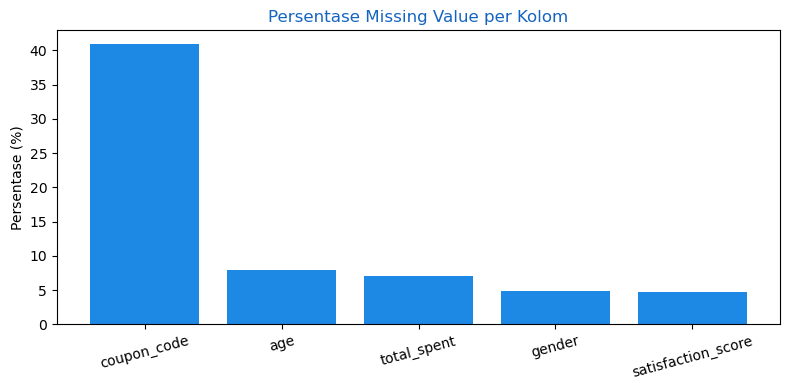

In [5]:
# Hitung persentase missing value
missing = df.isnull().sum()
missing_persen = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah': missing,
    'Persentase (%)': missing_persen
})
missing_df = missing_df[missing_df['Jumlah'] > 0].sort_values('Persentase (%)', ascending=False)

print(missing_df)

# Visualisasi bar chart
plt.figure(figsize=(8, 4))
plt.bar(missing_df.index, missing_df['Persentase (%)'], color=BIRU)
plt.title('Persentase Missing Value per Kolom', color=BIRU_TUA)
plt.ylabel('Persentase (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Insight:**
- `coupon_code` memiliki **40.89%** missing value, akan di-drop saat preprocessing.
- `age` (8.00%), `total_spent` (7.00%), `gender` (4.92%), dan `satisfaction_score` (4.68%) akan diimputasi dengan median atau modus.

### 1.3 Distribusi Target (Churn)

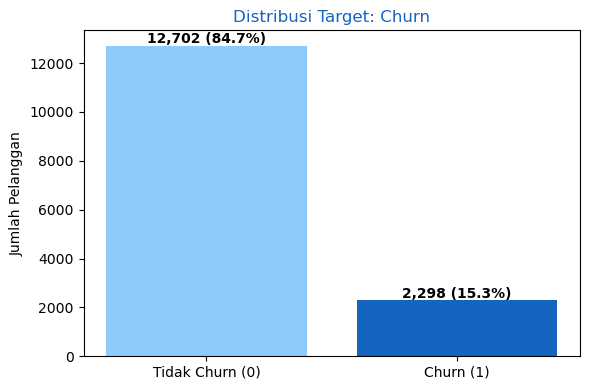

In [6]:
jumlah_churn = df['churn'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['Tidak Churn (0)', 'Churn (1)'], jumlah_churn.values, color=[BIRU_MUDA, BIRU_TUA])
plt.title('Distribusi Target: Churn', color=BIRU_TUA)
plt.ylabel('Jumlah Pelanggan')

for i, val in enumerate(jumlah_churn.values):
    persen = val / len(df) * 100
    plt.text(i, val + 100, f'{val:,} ({persen:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Data **tidak seimbang (imbalanced)**: 84.7% tidak churn (12.702) vs 15.3% churn (2.298).
- Akan ditangani dengan **SMOTE** pada tahap preprocessing.

### 1.4 Heatmap Korelasi Fitur Numerik

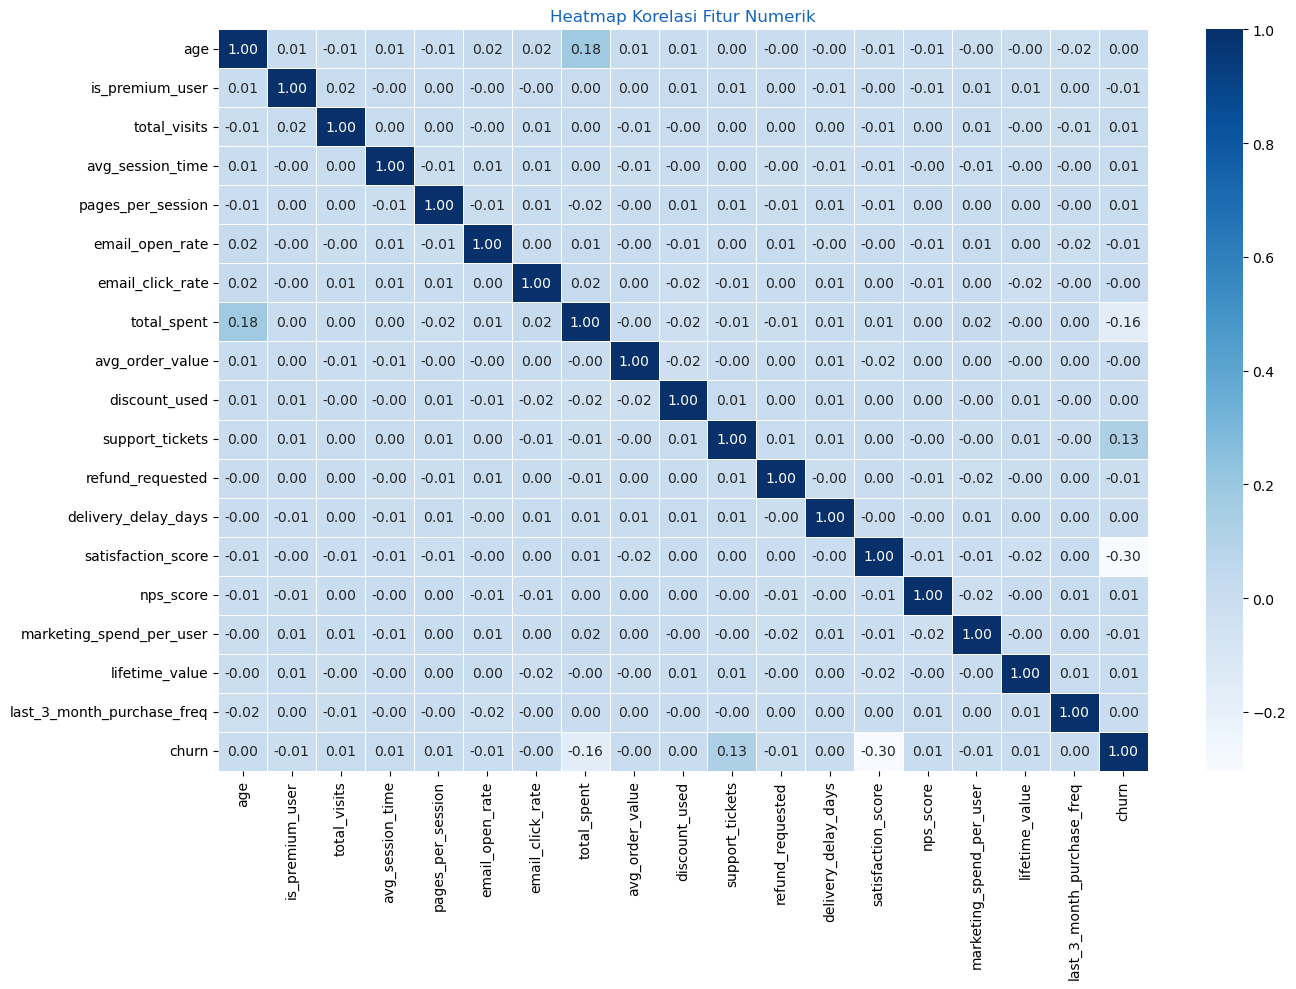

In [7]:
# Ambil hanya kolom numerik, kecuali customer_id
kolom_numerik = df.select_dtypes(include='number').columns.tolist()
kolom_numerik.remove('customer_id')

korelasi = df[kolom_numerik].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik', color=BIRU_TUA)
plt.tight_layout()
plt.show()

**Insight:**
- `satisfaction_score` memiliki korelasi negatif paling kuat dengan `churn` (**-0.30**): semakin rendah kepuasan pelanggan, semakin besar kemungkinan churn.
- `total_spent` juga berkorelasi negatif dengan `churn` (**-0.16**): pelanggan yang jarang belanja lebih berisiko churn.
- `support_tickets` berkorelasi positif dengan `churn` (**0.13**): semakin banyak tiket keluhan, semakin tinggi risiko churn.
- `total_spent` dan `age` memiliki korelasi positif (**0.18**): pelanggan yang lebih tua cenderung berbelanja lebih banyak.
- Secara keseluruhan, korelasi antar fitur terhadap churn tergolong **lemah hingga sedang** — ini wajar karena churn dipengaruhi banyak faktor kompleks.

## 2. Direct Modeling (Tanpa Preprocessing)

Model dilatih **langsung tanpa preprocessing**. Karena scikit-learn tidak bisa menerima
kolom bertipe teks (string), hanya kolom numerik yang digunakan dan baris dengan nilai
kosong (NaN) di-drop.

### 2.1 Persiapan Data

In [8]:
# Pilih hanya kolom numerik sebagai fitur
fitur_numerik = [
    'age', 'is_premium_user', 'total_visits', 'avg_session_time',
    'pages_per_session', 'email_open_rate', 'email_click_rate',
    'total_spent', 'avg_order_value', 'discount_used',
    'support_tickets', 'refund_requested', 'delivery_delay_days',
    'satisfaction_score', 'nps_score', 'marketing_spend_per_user',
    'lifetime_value', 'last_3_month_purchase_freq'
]

# Drop baris yang ada NaN (direct = tanpa preprocessing)
df_direct = df[fitur_numerik + ['churn']].dropna()

x = df_direct[fitur_numerik]
y = df_direct['churn']

# Split 80% train, 20% test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Jumlah data setelah drop NaN:', len(df_direct))
print('Data train:', x_train.shape)
print('Data test :', x_test.shape)

Jumlah data setelah drop NaN: 12246
Data train: (9796, 18)
Data test : (2450, 18)


### 2.2 Training dan Evaluasi Model

In [9]:
# Fungsi untuk evaluasi model (digunakan di semua skenario)
def evaluasi(nama, model, x_test, y_test):
    y_pred = model.predict(x_test)

    print(f'=== {nama} ===')
    print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
    print('Precision:', round(precision_score(y_test, y_pred, zero_division=0), 4))
    print('Recall   :', round(recall_score(y_test, y_pred, zero_division=0), 4))
    print('F1-Score :', round(f1_score(y_test, y_pred, zero_division=0), 4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {nama}', color=BIRU_TUA)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

    return {
        'Model': nama,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_test, y_pred, zero_division=0), 4)
    }

# List untuk menyimpan semua hasil
semua_hasil = []

#### a. Logistic Regression (Model Konvensional)

=== Logistic Regression - Direct ===
Accuracy : 0.8449
Precision: 0.5385
Recall   : 0.162
F1-Score : 0.249


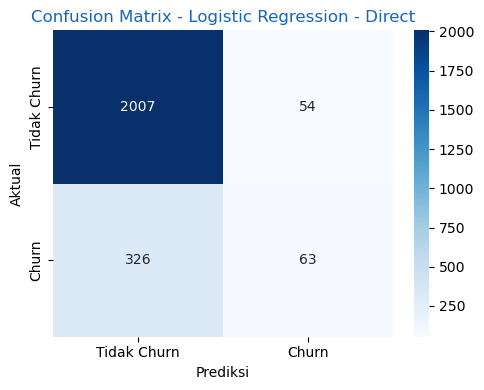

In [10]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(x_train, y_train)

hasil = evaluasi('Logistic Regression - Direct', model_lr, x_test, y_test)
hasil['Skenario'] = 'Direct'
semua_hasil.append(hasil)

#### b. Random Forest (Ensemble Bagging)

=== Random Forest - Direct ===
Accuracy : 0.8351
Precision: 0.4776
Recall   : 0.4113
F1-Score : 0.442


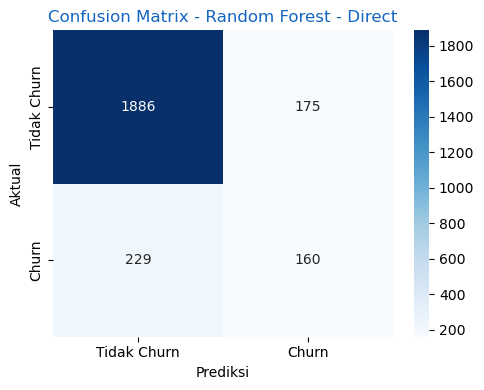

In [11]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x_train, y_train)

hasil = evaluasi('Random Forest - Direct', model_rf, x_test, y_test)
hasil['Skenario'] = 'Direct'
semua_hasil.append(hasil)

#### c. VotingClassifier (Ensemble Voting)

VotingClassifier menggabungkan tiga model: Logistic Regression, KNN, dan Decision Tree.

=== VotingClassifier - Direct ===
Accuracy : 0.8351
Precision: 0.4664
Recall   : 0.2674
F1-Score : 0.3399


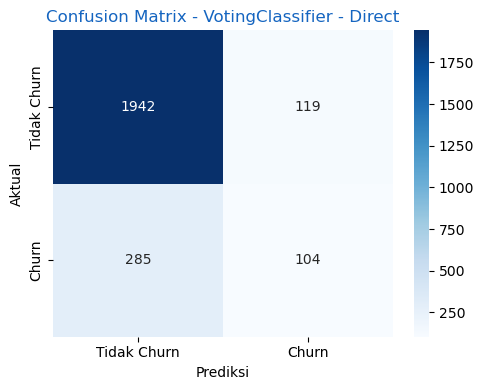

In [12]:
estimator = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

model_voting = VotingClassifier(estimators=estimator, voting='soft')
model_voting.fit(x_train, y_train)

hasil = evaluasi('VotingClassifier - Direct', model_voting, x_test, y_test)
hasil['Skenario'] = 'Direct'
semua_hasil.append(hasil)

## 3. Modeling dengan Preprocessing

### 3.1 Preprocessing Data

#### a. Penanganan Missing Value dan Duplikat

In [13]:
df_bersih = df.copy()

# Hapus kolom yang tidak relevan
kolom_hapus = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code', 'city', 'country']
df_bersih = df_bersih.drop(columns=kolom_hapus)

# Hapus duplikat
print('Jumlah duplikat:', df_bersih.duplicated().sum())
df_bersih = df_bersih.drop_duplicates()

# Isi missing value
df_bersih['gender']             = df_bersih['gender'].fillna(df_bersih['gender'].mode()[0])
df_bersih['age']                = df_bersih['age'].fillna(df_bersih['age'].median())
df_bersih['total_spent']        = df_bersih['total_spent'].fillna(df_bersih['total_spent'].median())
df_bersih['satisfaction_score'] = df_bersih['satisfaction_score'].fillna(df_bersih['satisfaction_score'].median())

print('Sisa missing value:', df_bersih.isnull().sum().sum())
print('Shape setelah preprocessing awal:', df_bersih.shape)

Jumlah duplikat: 0
Sisa missing value: 0
Shape setelah preprocessing awal: (15000, 24)


#### b. Penanganan Outlier (IQR Clipping)

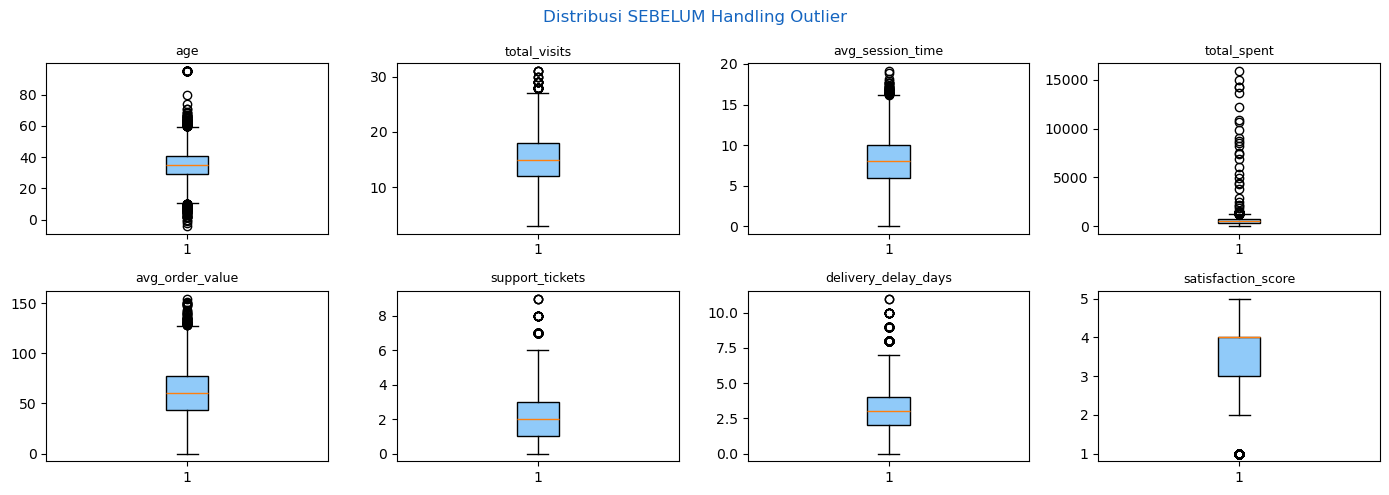

In [14]:
kolom_outlier = [
    'age', 'total_visits', 'avg_session_time', 'total_spent',
    'avg_order_value', 'support_tickets', 'delivery_delay_days', 'satisfaction_score'
]

# Visualisasi SEBELUM
plt.figure(figsize=(14, 5))
for i, kolom in enumerate(kolom_outlier):
    plt.subplot(2, 4, i + 1)
    plt.boxplot(df_bersih[kolom], patch_artist=True,
                boxprops=dict(facecolor=BIRU_MUDA))
    plt.title(kolom, fontsize=9)
plt.suptitle('Distribusi SEBELUM Handling Outlier', color=BIRU_TUA, fontsize=12)
plt.tight_layout()
plt.show()

Outlier selesai ditangani.


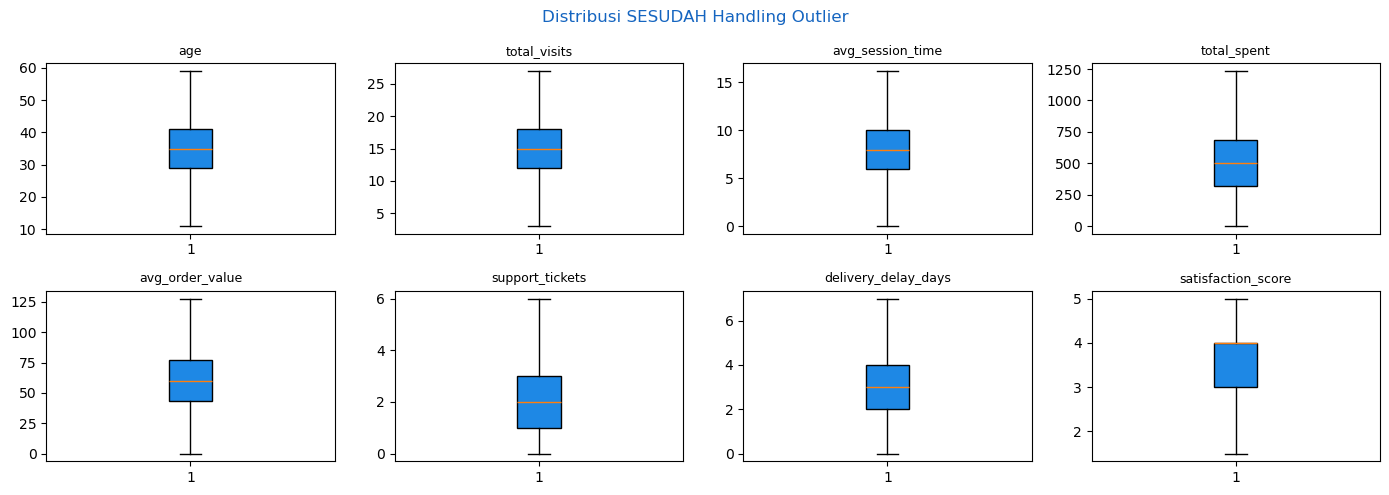

In [15]:
# Tangani outlier dengan IQR Clipping
for kolom in kolom_outlier:
    Q1 = df_bersih[kolom].quantile(0.25)
    Q3 = df_bersih[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR
    df_bersih[kolom] = df_bersih[kolom].clip(lower=batas_bawah, upper=batas_atas)

print('Outlier selesai ditangani.')

# Visualisasi SESUDAH
plt.figure(figsize=(14, 5))
for i, kolom in enumerate(kolom_outlier):
    plt.subplot(2, 4, i + 1)
    plt.boxplot(df_bersih[kolom], patch_artist=True,
                boxprops=dict(facecolor=BIRU))
    plt.title(kolom, fontsize=9)
plt.suptitle('Distribusi SESUDAH Handling Outlier', color=BIRU_TUA, fontsize=12)
plt.tight_layout()
plt.show()

#### c. Encoding Fitur Kategorikal

In [16]:
# Label Encoding untuk fitur dengan 2 kategori
le = LabelEncoder()
df_bersih['gender']            = le.fit_transform(df_bersih['gender'])
df_bersih['subscription_type'] = df_bersih['subscription_type'].map({'Annual': 0, 'Monthly': 1})

# One-Hot Encoding untuk fitur dengan banyak kategori
df_bersih = pd.get_dummies(df_bersih,
                            columns=['device_type', 'acquisition_channel', 'payment_method'],
                            drop_first=True)

# Ganti spasi di nama kolom dengan underscore
df_bersih.columns = df_bersih.columns.str.replace(' ', '_')

print('Shape setelah encoding:', df_bersih.shape)

Shape setelah encoding: (15000, 31)


#### d. Split Data, SMOTE, dan Scaling

In [17]:
x2 = df_bersih.drop(columns=['churn'])
y2 = df_bersih['churn']

nama_fitur = x2.columns.tolist()

# Split 80:20 (proporsi sama seperti skenario direct)
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42, stratify=y2)

print('Data train:', x2_train.shape)
print('Data test :', x2_test.shape)
print('Distribusi churn train sebelum SMOTE:', dict(y2_train.value_counts()))

# SMOTE hanya diterapkan pada data TRAIN
smote = SMOTE(random_state=42)
x2_train, y2_train = smote.fit_resample(x2_train, y2_train)

print('Distribusi churn train setelah SMOTE :', dict(pd.Series(y2_train).value_counts()))

# Scaling: fit pada train saja, transform pada train dan test
scaler   = StandardScaler()
x2_train = scaler.fit_transform(x2_train)
x2_test  = scaler.transform(x2_test)

Data train: (12000, 30)
Data test : (3000, 30)
Distribusi churn train sebelum SMOTE: {0: np.int64(10162), 1: np.int64(1838)}
Distribusi churn train setelah SMOTE : {1: np.int64(10162), 0: np.int64(10162)}


### 3.2 Training dan Evaluasi Model (dengan Preprocessing)

#### a. Logistic Regression

=== Logistic Regression - Preprocessing ===
Accuracy : 0.8033
Precision: 0.375
Recall   : 0.4239
F1-Score : 0.398


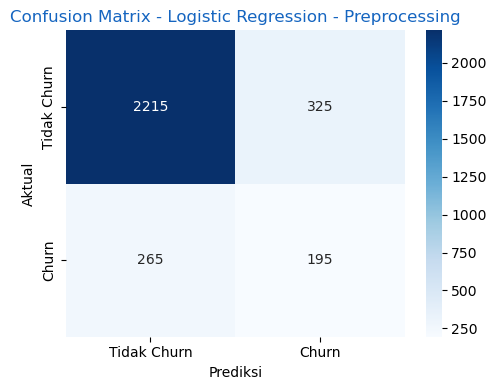

In [18]:
model_lr2 = LogisticRegression(random_state=42, max_iter=1000)
model_lr2.fit(x2_train, y2_train)

hasil = evaluasi('Logistic Regression - Preprocessing', model_lr2, x2_test, y2_test)
hasil['Skenario'] = 'Preprocessing'
semua_hasil.append(hasil)

#### b. Random Forest

=== Random Forest - Preprocessing ===
Accuracy : 0.8577
Precision: 0.528
Recall   : 0.6761
F1-Score : 0.5929


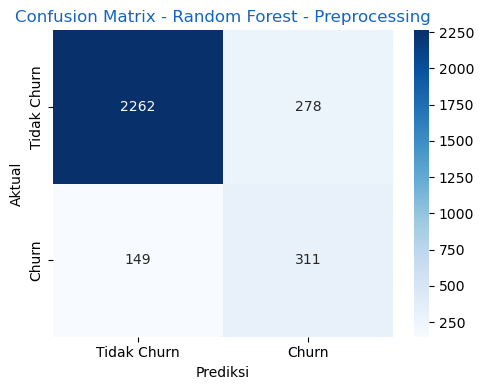

In [19]:
model_rf2 = RandomForestClassifier(random_state=42)
model_rf2.fit(x2_train, y2_train)

hasil = evaluasi('Random Forest - Preprocessing', model_rf2, x2_test, y2_test)
hasil['Skenario'] = 'Preprocessing'
semua_hasil.append(hasil)

#### c. VotingClassifier

=== VotingClassifier - Preprocessing ===
Accuracy : 0.842
Precision: 0.4815
Recall   : 0.3957
F1-Score : 0.4344


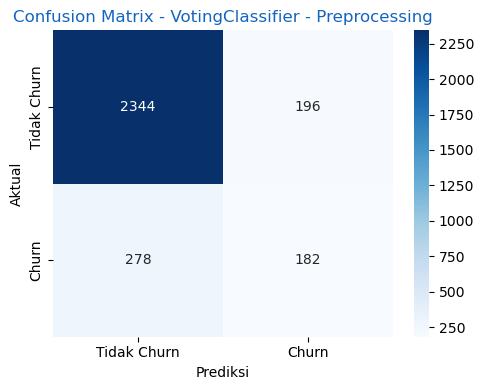

In [20]:
estimator2 = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

model_voting2 = VotingClassifier(estimators=estimator2, voting='soft')
model_voting2.fit(x2_train, y2_train)

hasil = evaluasi('VotingClassifier - Preprocessing', model_voting2, x2_test, y2_test)
hasil['Skenario'] = 'Preprocessing'
semua_hasil.append(hasil)

## 4. Hyperparameter Tuning dan Feature Selection

### 4.1 Feature Importance

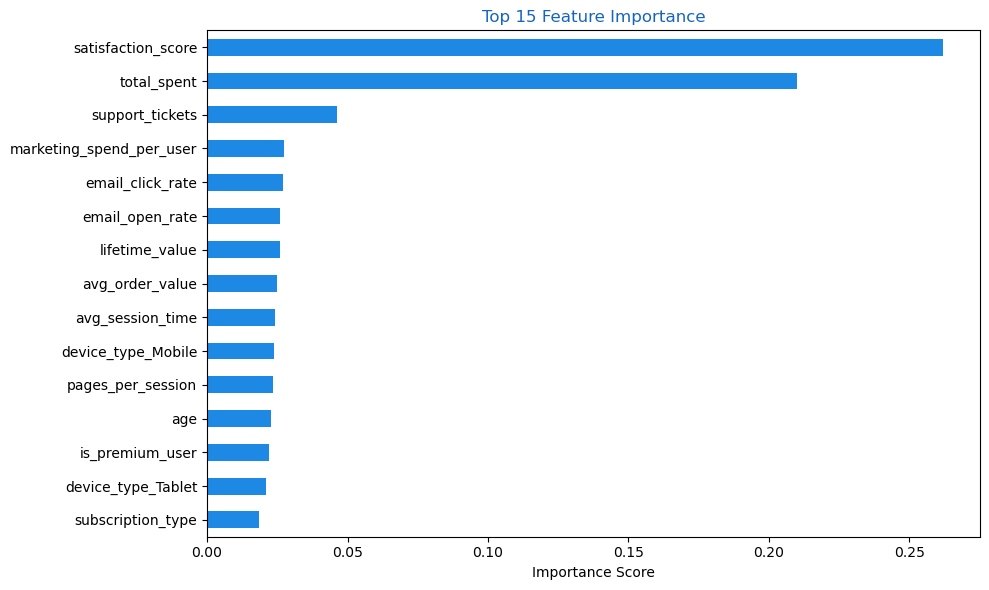

Top 15 fitur terpilih: ['satisfaction_score', 'total_spent', 'support_tickets', 'marketing_spend_per_user', 'email_click_rate', 'email_open_rate', 'lifetime_value', 'avg_order_value', 'avg_session_time', 'device_type_Mobile', 'pages_per_session', 'age', 'is_premium_user', 'device_type_Tablet', 'subscription_type']


In [21]:
# Gunakan feature importance dari Random Forest yang sudah dilatih
importances = pd.Series(model_rf2.feature_importances_, index=nama_fitur)
importances = importances.sort_values(ascending=False)

top_15_fitur = importances.head(15).index.tolist()

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color=BIRU)
plt.title('Top 15 Feature Importance', color=BIRU_TUA)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 15 fitur terpilih:', top_15_fitur)

### 4.2 Feature Selection

In [22]:
# Pilih hanya top 15 fitur untuk proses tuning
idx_top = [nama_fitur.index(f) for f in top_15_fitur]

x3_train = x2_train[:, idx_top]
x3_test  = x2_test[:, idx_top]

print('Shape data tuning - Train:', x3_train.shape)
print('Shape data tuning - Test :', x3_test.shape)

Shape data tuning - Train: (20324, 15)
Shape data tuning - Test : (3000, 15)


### 4.3 Hyperparameter Tuning

#### a. Logistic Regression

In [23]:
param_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000, 2000]
}

cv_lr = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    param_distributions=param_lr,
    n_iter=20, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
cv_lr.fit(x3_train, y2_train)

print('Best params :', cv_lr.best_params_)
print('Best F1 (CV):', round(cv_lr.best_score_, 4))

Best params : {'solver': 'liblinear', 'max_iter': 2000, 'C': 0.001}
Best F1 (CV): 0.7902


=== Logistic Regression - Tuning ===
Accuracy : 0.756
Precision: 0.3345
Recall   : 0.5978
F1-Score : 0.429


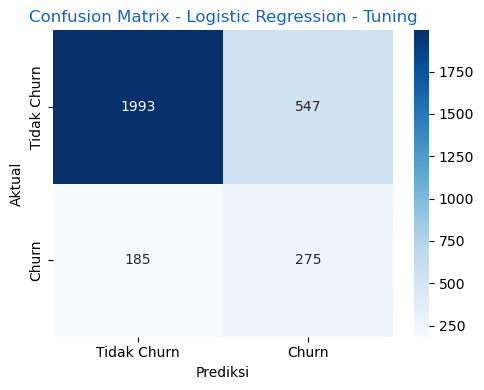

In [24]:
lr_terbaik = cv_lr.best_estimator_

hasil = evaluasi('Logistic Regression - Tuning', lr_terbaik, x3_test, y2_test)
hasil['Skenario'] = 'Tuning'
semua_hasil.append(hasil)

#### b. Random Forest

In [25]:
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_rf,
    n_iter=20, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
cv_rf.fit(x3_train, y2_train)

print('Best params :', cv_rf.best_params_)
print('Best F1 (CV):', round(cv_rf.best_score_, 4))

Best params : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}
Best F1 (CV): 0.8891


=== Random Forest - Tuning ===
Accuracy : 0.8513
Precision: 0.51
Recall   : 0.7761
F1-Score : 0.6155


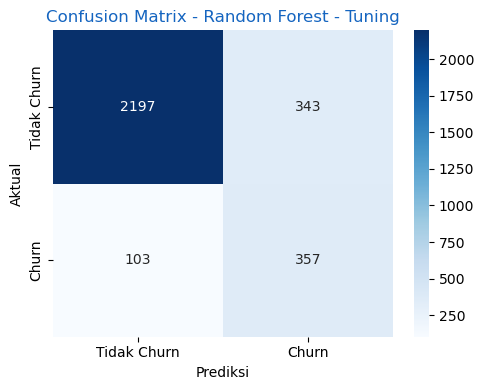

In [26]:
rf_terbaik = cv_rf.best_estimator_

hasil = evaluasi('Random Forest - Tuning', rf_terbaik, x3_test, y2_test)
hasil['Skenario'] = 'Tuning'
semua_hasil.append(hasil)

#### c. VotingClassifier

In [27]:
estimator3 = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

param_voting = {
    'lr__C': [0.01, 0.1, 1, 10],
    'knn__n_neighbors': [3, 5, 7, 11],
    'dt__max_depth': [3, 5, 7, None]
}

cv_voting = RandomizedSearchCV(
    VotingClassifier(estimators=estimator3, voting='soft'),
    param_distributions=param_voting,
    n_iter=20, cv=3, scoring='f1', random_state=42, n_jobs=-1
)
cv_voting.fit(x3_train, y2_train)

print('Best params :', cv_voting.best_params_)
print('Best F1 (CV):', round(cv_voting.best_score_, 4))

Best params : {'lr__C': 1, 'knn__n_neighbors': 3, 'dt__max_depth': 7}
Best F1 (CV): 0.8949


=== VotingClassifier - Tuning ===
Accuracy : 0.8313
Precision: 0.4655
Recall   : 0.6739
F1-Score : 0.5506


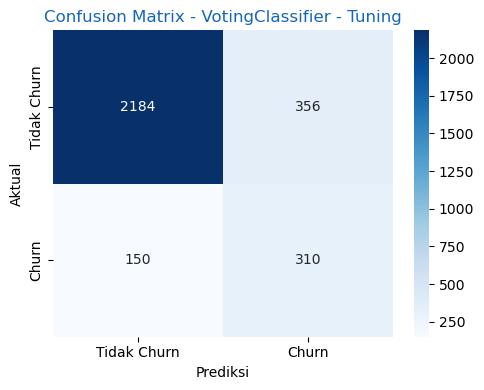

In [28]:
voting_terbaik = cv_voting.best_estimator_

hasil = evaluasi('VotingClassifier - Tuning', voting_terbaik, x3_test, y2_test)
hasil['Skenario'] = 'Tuning'
semua_hasil.append(hasil)

## 5. Perbandingan Model dan Deployment

### 5.1 Tabel Perbandingan Semua Model

In [29]:
df_hasil = pd.DataFrame(semua_hasil)
df_hasil = df_hasil[['Skenario', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
df_hasil

,Skenario,Model,Accuracy,Precision,Recall,F1-Score
0,Direct,Logistic Regression - Direct,0.8449,0.5385,0.1620,0.2490
1,Direct,Random Forest - Direct,0.8351,0.4776,0.4113,0.4420
2,Direct,VotingClassifier - Direct,0.8351,0.4664,0.2674,0.3399
3,Preprocessing,Logistic Regression - Preprocessing,0.8033,0.3750,0.4239,0.3980
4,Preprocessing,Random Forest - Preprocessing,0.8577,0.5280,0.6761,0.5929
5,Preprocessing,VotingClassifier - Preprocessing,0.8420,0.4815,0.3957,0.4344
6,Tuning,Logistic Regression - Tuning,0.7560,0.3345,0.5978,0.4290
7,Tuning,Random Forest - Tuning,0.8513,0.5100,0.7761,0.6155
8,Tuning,VotingClassifier - Tuning,0.8313,0.4655,0.6739,0.5506


### 5.2 Visualisasi Perbandingan F1-Score dan Recall per Skenario

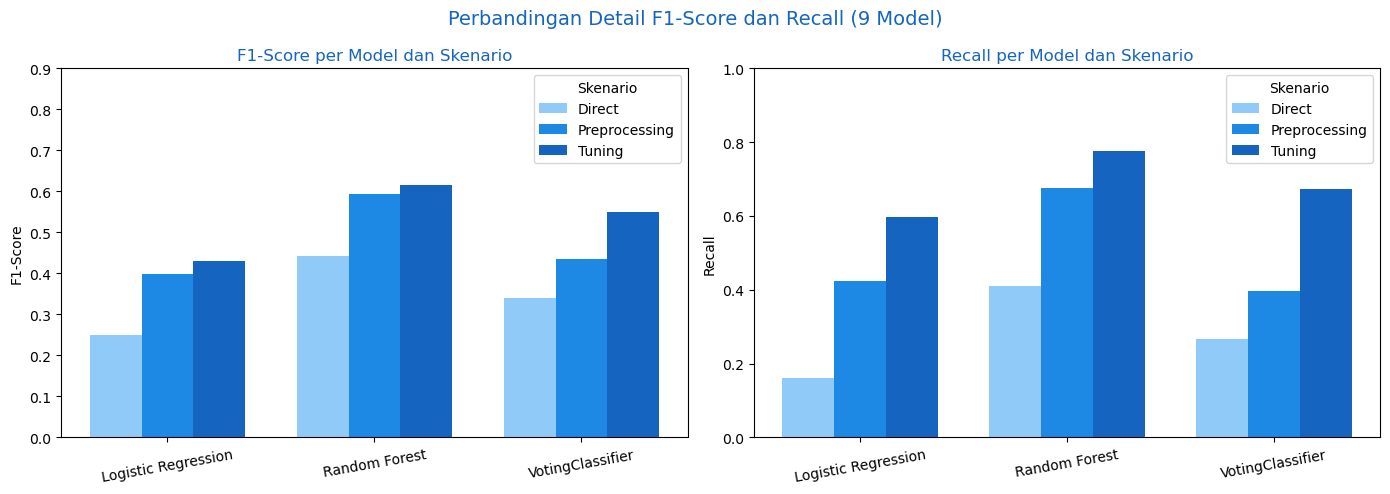

In [30]:
# Perbandingan F1-Score dan Recall per model di tiap skenario
skenario_list = ['Direct', 'Preprocessing', 'Tuning']
model_list    = ['Logistic Regression', 'Random Forest', 'VotingClassifier']
warna_list    = [BIRU_MUDA, BIRU, BIRU_TUA]

x     = np.arange(len(model_list))
lebar = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (skenario, warna) in enumerate(zip(skenario_list, warna_list)):
    data = df_hasil[df_hasil['Skenario'] == skenario].sort_values('Model')
    axes[0].bar(x + i * lebar, data['F1-Score'].values, lebar, label=skenario, color=warna)
    axes[1].bar(x + i * lebar, data['Recall'].values,   lebar, label=skenario, color=warna)

# Plot kiri - F1
axes[0].set_title('F1-Score per Model dan Skenario', color=BIRU_TUA, fontsize=12)
axes[0].set_ylabel('F1-Score')
axes[0].set_xticks(x + lebar)
axes[0].set_xticklabels(model_list, rotation=10)
axes[0].set_ylim(0, 0.9)
axes[0].legend(title='Skenario')

# Plot kanan - Recall
axes[1].set_title('Recall per Model dan Skenario', color=BIRU_TUA, fontsize=12)
axes[1].set_ylabel('Recall')
axes[1].set_xticks(x + lebar)
axes[1].set_xticklabels(model_list, rotation=10)
axes[1].set_ylim(0, 1.0)
axes[1].legend(title='Skenario')

plt.suptitle('Perbandingan Detail F1-Score dan Recall (9 Model)', color=BIRU_TUA, fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Model Terbaik

In [31]:
baris_terbaik = df_hasil.loc[df_hasil['F1-Score'].idxmax()]
print('Model Terbaik:', baris_terbaik['Model'])
print('Skenario     :', baris_terbaik['Skenario'])
print('Accuracy     :', baris_terbaik['Accuracy'])
print('Precision    :', baris_terbaik['Precision'])
print('Recall       :', baris_terbaik['Recall'])
print('F1-Score     :', baris_terbaik['F1-Score'])

Model Terbaik: Random Forest - Tuning
Skenario     : Tuning
Accuracy     : 0.8513
Precision    : 0.51
Recall       : 0.7761
F1-Score     : 0.6155


### 5.4 Simpan Model untuk Deployment

In [32]:
os.makedirs('../model', exist_ok=True)

# Simpan model terbaik (Random Forest - Tuning)
joblib.dump(rf_terbaik,    '../model/best_model.pkl')
joblib.dump(scaler,         '../model/scaler.pkl')
joblib.dump(nama_fitur,     '../model/feature_columns.pkl')
joblib.dump(top_15_fitur,   '../model/top_feature_names.pkl')

# Simpan nilai untuk imputasi di aplikasi Streamlit
nilai_imputasi = {
    'gender'            : df['gender'].mode()[0],
    'age'               : df['age'].median(),
    'total_spent'       : df['total_spent'].median(),
    'satisfaction_score': df['satisfaction_score'].median()
}
joblib.dump(nilai_imputasi, '../model/impute_values.pkl')

print('Model dan file pendukung berhasil disimpan ke folder model/')
print('File tersimpan:', os.listdir('../model/'))

Model dan file pendukung berhasil disimpan ke folder model/
File tersimpan: ['scaler.pkl', 'top_feature_names.pkl', 'impute_values.pkl', 'feature_columns.pkl', 'best_model.pkl']


## Kesimpulan

### Ringkasan Performa 9 Model

| Skenario | Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| Direct | Logistic Regression | 0.8449 | 0.5385 | 0.1620 | 0.2490 |
| Direct | Random Forest | 0.8351 | 0.4776 | 0.4113 | 0.4420 |
| Direct | VotingClassifier | 0.8351 | 0.4664 | 0.2674 | 0.3399 |
| Preprocessing | Logistic Regression | 0.8033 | 0.3750 | 0.4239 | 0.3980 |
| Preprocessing | Random Forest | 0.8577 | 0.5280 | 0.6761 | 0.5929 |
| Preprocessing | VotingClassifier | 0.8420 | 0.4815 | 0.3957 | 0.4344 |
| Tuning | Logistic Regression | 0.7560 | 0.3345 | 0.5978 | 0.4290 |
| **Tuning** | **Random Forest** | **0.8513** | **0.5100** | **0.7761** | **0.6155** |
| Tuning | VotingClassifier | 0.8313 | 0.4655 | 0.6739 | 0.5506 |

**Model terbaik: Random Forest - Tuning (F1-Score = 0.6155, Recall = 0.7761)**

- SMOTE sangat membantu meningkatkan Recall dari 41% (Direct) menjadi 68% (Preprocessing) dan 77% (Tuning).
- Preprocessing adalah langkah paling berdampak dalam keseluruhan pipeline.
- Random Forest konsisten menjadi model terbaik di semua skenario.